In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Question 4

Nous pouvons considéré un seul véhicule car ils ont tous la même charge maximale et le même $\beta$.

On a $\forall i \in [0; N-1], Q_{i+1} = Q_i + \Delta t\beta P_i$

Ainsi : $\forall i \in [0; N-1], \beta P_i = (SOC_{i+1}-SOC_i)Q_{barre}/\Delta t$ qui va constituer notre problème des moindres carrés. 

Question 5 :

On veut résoudre Ax = b avec A qui est la matrice des puissances


In [3]:
#Question 5
U_sec = 230
Q_barre = 50*3600

data = pd.read_csv("data_battery.csv")
N = len(data)

time = np.array(data["Time [s]"])
list_A = np.array(U_sec*data["I [kA]"]) 
A = list_A[:N-1]
A = A.reshape((N-1, 1))

SOC = np.array(data["SOC [%]"])
b = (SOC[1:]-SOC[:N-1])*Q_barre/(time[1:]-time[:N-1])
b = b.reshape((N-1,1))

#Pour le problème des moindres carrés, on peut prendre la solution explicite : Beta = (A^T*A)^{-1}*(A^T*b) ou utiliser la fonction np.linalg.lstsq pour résoudre Ax = b
sol = np.linalg.lstsq(A, b) #sol[0] = beta ; sol[1] = somme des résidus ; sol[2] = rang de la matrice A ; sol[3] = valeur singulière de A
beta = sol[0][0][0]

print("La valeur de beta trouvé pour les données brut est :", beta)

La valeur de beta trouvé pour les données brut est : 2.982908229641423


In [4]:
#Estimation de la charge de la batterie à partir de la valeur Beta

#initialisation
SOC_estime = np.zeros(N)
SOC_estime[0] = data["SOC [%]"].iloc[0]

#Récurrence
for i in range(1, N):
    SOC_estime[i]=SOC_estime[i-1] + (time[i]-time[i-1])*beta*list_A[i]/Q_barre

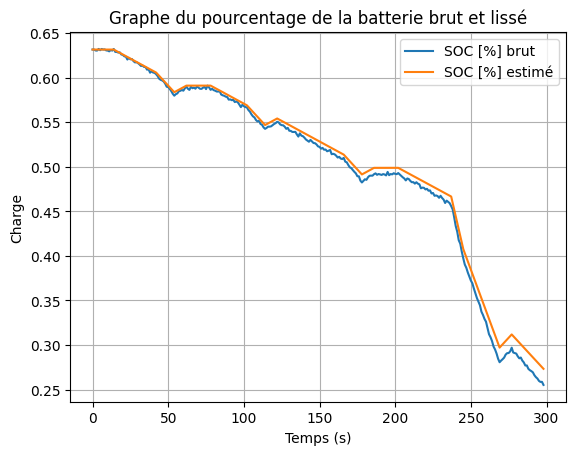

In [5]:
#Affichage du graphe de la batterie
data = pd.read_csv("data_battery.csv")
data["SOC [%] brut"] = data["SOC [%]"]
data['SOC [%] lissé'] = data["SOC [%]"].rolling(window = 5, on = data.index).mean()
data['SOC [%] estimé'] = SOC_estime
data[['SOC [%] brut', 'SOC [%] estimé']].plot(title = "Graphe du pourcentage de la batterie brut et lissé")
plt.xlabel("Temps (s)")
plt.ylabel("Charge")
plt.grid()
plt.show()

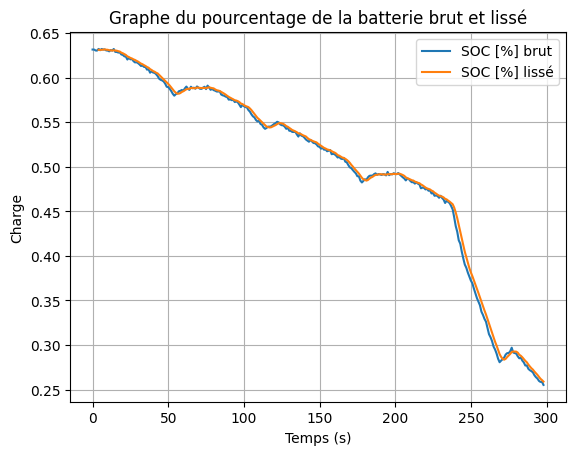

In [6]:
#Affichage du graphe de la batterie
data = pd.read_csv("data_battery.csv")
data["SOC [%] brut"] = data["SOC [%]"]
data['SOC [%] lissé'] = data["SOC [%]"].rolling(window = 5, on = data.index).mean()
data[['SOC [%] brut', 'SOC [%] lissé']].plot(title = "Graphe du pourcentage de la batterie brut et lissé")
plt.xlabel("Temps (s)")
plt.ylabel("Charge")
plt.grid()
plt.show()

La valeur de beta trouvé pour les données brutes est : 0.002982908229641423


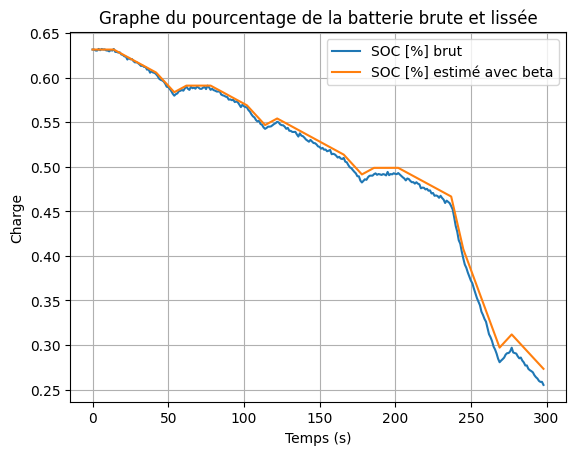

In [21]:
#Question 5
U_sec = 230
Q_barre = 50*3600

data = pd.read_csv("data_battery.csv")
N = len(data)

time = np.array(data["Time [s]"])
list_A = np.array(1000*U_sec*data["I [kA]"]) 
A = list_A[:N-1]
A = A.reshape((N-1, 1))

SOC = np.array(data["SOC [%]"])
b = (SOC[1:]-SOC[:N-1])*Q_barre/(time[1:]-time[:N-1])
b = b.reshape((N-1,1))

#Pour le problème des moindres carrés, on peut prendre la solution explicite : Beta = (A^T*A)^{-1}*(A^T*b) ou utiliser la fonction np.linalg.lstsq pour résoudre Ax = b
sol = np.linalg.lstsq(A, b) #sol[0] = beta ; sol[1] = somme des résidus ; sol[2] = rang de la matrice A ; sol[3] = valeur singulière de A
beta = sol[0][0][0]

print("La valeur de beta trouvé pour les données brutes est :", beta)

#Estimation de la charge de la batterie à partir de la valeur Beta

#initialisation
SOC_estime = np.zeros(N)
SOC_estime[0] = data["SOC [%]"].iloc[0]

#Récurrence
for i in range(1, N):
    SOC_estime[i]=SOC_estime[i-1] + (time[i]-time[i-1])*beta*list_A[i]/Q_barre

#Affichage du graphe de la batterie
data["SOC [%] brut"] = data["SOC [%]"]
data['SOC [%] lissé'] = data["SOC [%]"].rolling(window = 5, on = data.index).mean()
data['SOC [%] estimé avec beta'] = SOC_estime
data[['SOC [%] brut', 'SOC [%] estimé avec beta']].plot(title = "Graphe du pourcentage de la batterie brute et lissée")
plt.xlabel("Temps (s)")
plt.ylabel("Charge")
plt.grid()
plt.show()

La valeur de beta trouvé pour les données lissées est : 0.0027900713004994403


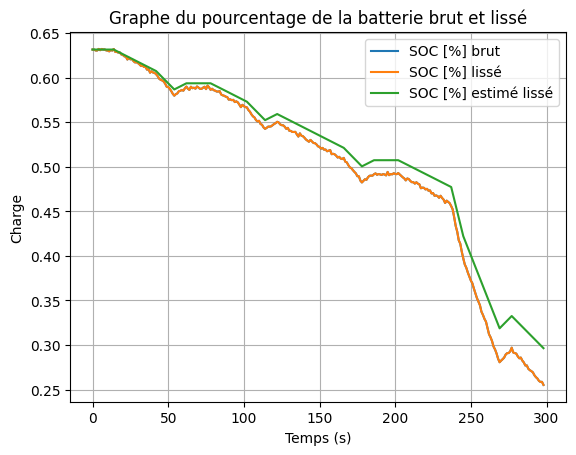

In [17]:
#Question 5
U_sec = 230
Q_barre = 50*3600
window = 1

data = pd.read_csv("data_battery.csv")
data['SOC [%] lissé'] = data["SOC [%]"].rolling(window = window).mean()
N = len(data)

time = np.array(data["Time [s]"])
list_A = np.array(1000*U_sec*data["I [kA]"]) 
A = list_A[:N-window-1]
A = A.reshape((N-window-1, 1))

SOC_lisse = np.array(data["SOC [%] lissé"])
b_lisse = (SOC_lisse[window+1:]-SOC_lisse[window:N-1])*Q_barre/(time[window+1:]-time[window:N-1])
b_lisse = b_lisse.reshape((N-window-1,1))

#Pour le problème des moindres carrés, on peut prendre la solution explicite : Beta = (A^T*A)^{-1}*(A^T*b) ou utiliser la fonction np.linalg.lstsq pour résoudre Ax = b
sol_lisse = np.linalg.lstsq(A, b_lisse) #sol[0] = beta ; sol[1] = somme des résidus ; sol[2] = rang de la matrice A ; sol[3] = valeur singulière de A
beta_lisse = sol_lisse[0][0][0]

print("La valeur de beta trouvé pour les données lissées est :", beta_lisse)

#Estimation de la charge de la batterie à partir de la valeur Beta

#initialisation
SOC_estime_lisse = np.zeros(N)
SOC_estime_lisse[0] = data["SOC [%]"].iloc[0]

#Récurrence
for i in range(1, N):
    SOC_estime_lisse[i]=SOC_estime_lisse[i-1] + (time[i]-time[i-1])*beta_lisse*list_A[i]/Q_barre

#Affichage du graphe de la batterie
data["SOC [%] brut"] = data["SOC [%]"]
data['SOC [%] estimé lissé'] = SOC_estime_lisse
data[['SOC [%] brut', 'SOC [%] lissé', 'SOC [%] estimé lissé']].plot(title = "Graphe du pourcentage de la batterie brut et lissé")
plt.xlabel("Temps (s)")
plt.ylabel("Charge")
plt.grid()
plt.show()

La valeur de beta trouvé pour les données lissées est : 0.002982908229641423


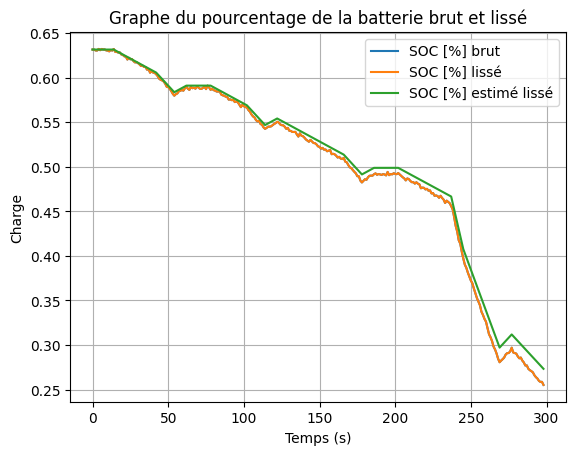

In [24]:

#Question 5
U_sec = 230
Q_barre = 50*3600
window = 0

data = pd.read_csv("data_battery.csv")
#data['SOC [%] lissé'] = data["SOC [%]"].rolling(window = window).mean()
data['SOC [%] lissé'] = data["SOC [%]"]
N = len(data)

time = np.array(data["Time [s]"])
list_A = np.array(1000*U_sec*data["I [kA]"]) 
A = list_A[:N-window-1]
A = A.reshape((N-window-1, 1))

SOC_lisse = np.array(data["SOC [%] lissé"])
b_lisse = (SOC_lisse[window+1:]-SOC_lisse[window:N-1])*Q_barre/(time[window+1:]-time[window:N-1])
b_lisse = b_lisse.reshape((N-window-1,1))

#Pour le problème des moindres carrés, on peut prendre la solution explicite : Beta = (A^T*A)^{-1}*(A^T*b) ou utiliser la fonction np.linalg.lstsq pour résoudre Ax = b
sol_lisse = np.linalg.lstsq(A, b_lisse) #sol[0] = beta ; sol[1] = somme des résidus ; sol[2] = rang de la matrice A ; sol[3] = valeur singulière de A
beta_lisse = sol_lisse[0][0][0]

print("La valeur de beta trouvé pour les données lissées est :", beta_lisse)

#Estimation de la charge de la batterie à partir de la valeur Beta

#initialisation
SOC_estime_lisse = np.zeros(N)
SOC_estime_lisse[0] = data["SOC [%]"].iloc[0]

#Récurrence
for i in range(1, N):
    SOC_estime_lisse[i]=SOC_estime_lisse[i-1] + (time[i]-time[i-1])*beta_lisse*list_A[i]/Q_barre

#Affichage du graphe de la batterie
data["SOC [%] brut"] = data["SOC [%]"]
data['SOC [%] estimé lissé'] = SOC_estime_lisse
data[['SOC [%] brut', 'SOC [%] lissé', 'SOC [%] estimé lissé']].plot(title = "Graphe du pourcentage de la batterie brut et lissé")
plt.xlabel("Temps (s)")
plt.ylabel("Charge")
plt.grid()
plt.show()


La valeur de beta trouvé pour les données lissées est : 0.0028833180009809807


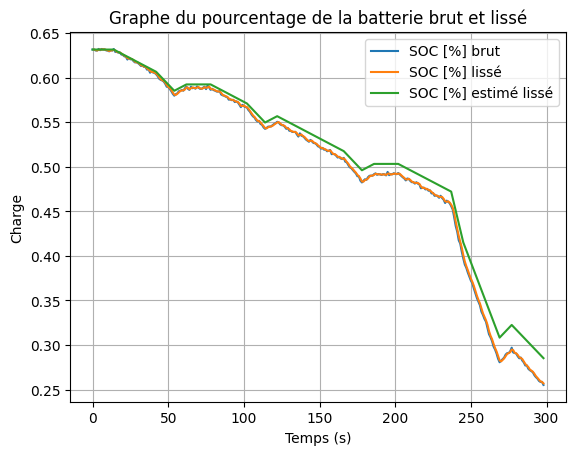

In [32]:
#Question 5
U_sec = 230
Q_barre = 50*3600
window = 2

data = pd.read_csv("data_battery.csv")
data['SOC [%] lissé'] = data["SOC [%]"].rolling(window = window).mean()
#data['SOC [%] lissé'] = data["SOC [%]"]
N = len(data)

time = np.array(data["Time [s]"])
list_A = np.array(1000*U_sec*data["I [kA]"]) 
A = list_A[:N-window]
A = A.reshape((N-window, 1))

SOC_lisse = np.array(data["SOC [%] lissé"])
b_lisse = (SOC_lisse[window:]-SOC_lisse[window-1:N-1])*Q_barre/(time[window:]-time[window-1:N-1])
b_lisse = b_lisse.reshape((N-window,1))

#Pour le problème des moindres carrés, on peut prendre la solution explicite : Beta = (A^T*A)^{-1}*(A^T*b) ou utiliser la fonction np.linalg.lstsq pour résoudre Ax = b
sol_lisse = np.linalg.lstsq(A, b_lisse) #sol[0] = beta ; sol[1] = somme des résidus ; sol[2] = rang de la matrice A ; sol[3] = valeur singulière de A
beta_lisse = sol_lisse[0][0][0]

print("La valeur de beta trouvé pour les données lissées est :", beta_lisse)

#Estimation de la charge de la batterie à partir de la valeur Beta

#initialisation
SOC_estime_lisse = np.zeros(N)
SOC_estime_lisse[0] = data["SOC [%]"].iloc[0]

#Récurrence
for i in range(1, N):
    SOC_estime_lisse[i]=SOC_estime_lisse[i-1] + (time[i]-time[i-1])*beta_lisse*list_A[i]/Q_barre

#Affichage du graphe de la batterie
data["SOC [%] brut"] = data["SOC [%]"]
data['SOC [%] estimé lissé'] = SOC_estime_lisse
data[['SOC [%] brut', 'SOC [%] lissé', 'SOC [%] estimé lissé']].plot(title = "Graphe du pourcentage de la batterie brut et lissé")
plt.xlabel("Temps (s)")
plt.ylabel("Charge")
plt.grid()
plt.show()


In [31]:
beta-beta_lisse

np.float64(9.959022866044224e-05)

In [ ]:
scipy.signal.filtfilt